<a href="https://colab.research.google.com/github/genaiconference/When-Agents-Meet-Living-Graphs/blob/main/CineCraft_AI_Director_Clone_with_Saga.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# The Living Graph Memory - Director's Digital AI Twin

### Graphiti demonstrated as an *evolving creative identity*, not a memory database

> **RAG remembers the director's notes.**
> **Graphiti remembers the director's mind changing.**
> **CineCraft AI, powered by Graphiti becomes the director's evolving digital twin.**

---

This notebook maps Graphiti's core mechanics to a memorable **seven-day “director clone” storyline**. Each cell demonstrates a distinct capability with a visible *before/after* effect.

The strongest demo is not *“the graph remembers seven notes.”* It is *“the clone can distinguish **what** the director believed, **when** it was true, **when** the system learned it, and **why** the decision changed.”*

## The seven-stage sequence

**PITCH → PRESSURE → PIVOT → PAST → PROOF → PATTERN → PERSONA**

| Stage | Meaning |
|-------|---------|
| **PITCH** | What the director initially imagined |
| **PRESSURE** | Real-world constraints arrive |
| **PIVOT** | The director changes the vision |
| **PAST** | An older idea is discovered later |
| **PROOF** | Every decision can be traced to its source |
| **PATTERN** | The graph discovers the director's recurring creative DNA |
| **PERSONA** | The AI clone speaks and decides like the director |

## The two clocks your audience must understand

Every important creative fact can have **two timelines**:

1. **Director time** — *When was the idea actually true?* → `valid_at`, `invalid_at`
2. **Memory time** — *When did CineCraft AI learn the idea?* → `created_at`, `expired_at`

> Arun decided on **Tuesday** that Aham represents Maya's father. But CineCraft AI only received the voice note on **Thursday**.
>
> Therefore: `valid_at = Tuesday`, `created_at = Thursday`.

This is the killer **bi-temporal** demonstration.

In [1]:
! git clone https://github.com/genaiconference/When-Agents-Meet-Living-Graphs.git

Cloning into 'When-Agents-Meet-Living-Graphs'...
remote: Enumerating objects: 194, done.
remote: Counting objects: 100% (54/54), done.
remote: Compressing objects: 100% (51/51), done.
remote: Total 194 (delta 28), reused 10 (delta 3), pack-reused 140 (from 2)
Receiving objects: 100% (194/194), 91.72 MiB | 12.97 MiB/s, done.
Resolving deltas: 100% (86/86), done.


## Setup: Install & Configure

Graphiti needs a Neo4j (or FalkorDB) backend and an LLM/embedder (OpenAI or Azure OpenAI). Set the environment variables below before running.

In [1]:
# Install dependencies (uncomment on first run)
%pip install graphiti_core==0.29.3 python-dotenv nest_asyncio markdown --quiet

In [2]:
import os
from datetime import datetime, timezone, timedelta
from dotenv import load_dotenv
import nest_asyncio

os.chdir("/content/When-Agents-Meet-Living-Graphs")

# Allow await in notebook cells
nest_asyncio.apply()
load_dotenv()

# ---- Backend / model configuration ----
NEO4J_URI = os.environ.get("NEO4J_URI")
NEO4J_USER = os.environ.get("NEO4J_USERNAME")
NEO4J_PASSWORD = os.environ.get("NEO4J_PASSWORD")

# OpenAI (or Azure OpenAI) keys are read from the environment by Graphiti
assert os.environ.get("OPENAI_API_KEY"), "Set OPENAI_API_KEY (or configure Azure clients below)"

print("Config loaded. Neo4j:", NEO4J_URI)

Config loaded. Neo4j: bolt://18.215.15.211


In [3]:
# A small helper so the whole week uses one consistent Monday-9am anchor.
# We build all the 'director-time' reference timestamps relative to this.
WEEK_MONDAY_9AM = datetime(2026, 6, 1, 9, 0, tzinfo=timezone.utc)  # a real Monday

def day(name, hour=9, minute=0):
    """Return a reference_time for a given weekday of the demo week."""
    offsets = {"MON": 0, "TUE": 1, "WED": 2, "THU": 3, "FRI": 4, "SAT": 5, "SUN": 6}
    base = WEEK_MONDAY_9AM.replace(hour=hour, minute=minute)
    return base + timedelta(days=offsets[name.upper()])

for d in ["MON", "TUE", "WED", "THU", "FRI", "SAT", "SUN"]:
    print(d, "->", day(d))

MON -> 2026-06-01 09:00:00+00:00
TUE -> 2026-06-02 09:00:00+00:00
WED -> 2026-06-03 09:00:00+00:00
THU -> 2026-06-04 09:00:00+00:00
FRI -> 2026-06-05 09:00:00+00:00
SAT -> 2026-06-06 09:00:00+00:00
SUN -> 2026-06-07 09:00:00+00:00


## Create the Director Clone

We define a **namespace** (`group_id`) so this director's mind lives in an isolated graph, a **saga id** for week-level summarisation, and a **custom ontology** of film-domain entities and relationships.

> Graphiti supports prescribed custom entity and edge types through Pydantic models. It can also let structure *emerge* when you do not prescribe everything upfront.

In [4]:
import asyncio
from graphiti_core import Graphiti

GROUP_ID = "director_arun_project_aham"

graphiti = Graphiti(NEO4J_URI, NEO4J_USER, NEO4J_PASSWORD)

await graphiti.build_indices_and_constraints()
print(f"Director clone namespace ready :", GROUP_ID)

Director clone namespace ready : director_arun_project_aham


In [5]:
from schema import entity_types, edge_types, edge_type_map
print(f"Ontology ready: {len(entity_types)} entity types, {len(edge_types)} edge types.")

Ontology ready: 20 entity types, 32 edge types.


## SAGA: chain the week's episodes into one coherent creative arc
A **saga** is a named, ordered thread of episodes.

Every episode we ingest this week (**Mon** pitch -> **Tue** constraints -> **Wed** pivot -> **Thu** adapt -> **Fri** feedback) is attached to the **SAME saga** and linked to the previous one, so Graphiti keeps them as a single evolving storyline.

In [6]:
# Define SAGA ID
SAGA_ID = "aham_creative_evolution_week_1"

### Graphiti Functions - Write & Search

Graphiti Write -> `graphiti.add_episode()`


Graphiti Search ->  `graphiti.search()`

In [7]:
from graphiti_core.nodes import EpisodeType
from openai import OpenAI
from utils import display_episode_summary, display_answer
from utils import EXTRACTION_INSTRUCTIONS, ANSWER_PROMPT,get_project_center, _fact_with_time

_llm = OpenAI()

# Tracks the uuid of the last episode added to the saga, so the next episode
# chains onto it via `saga_previous_episode_uuid` (strict Mon->Tue->Wed order).
_last_saga_episode_uuid = None


async def add_creative_episode(name, body, reference_time, source=EpisodeType.text,
                               description="", group_id=GROUP_ID):
    global _last_saga_episode_uuid
    result = await graphiti.add_episode(
        name=name,
        episode_body=body,
        source=source,
        source_description=description,
        reference_time=reference_time,
        group_id=group_id,
        entity_types=entity_types,
        edge_types=edge_types,
        edge_type_map=edge_type_map,
        custom_extraction_instructions=EXTRACTION_INSTRUCTIONS,
        saga=SAGA_ID,
        saga_previous_episode_uuid=_last_saga_episode_uuid,
    )
    # Chain the next episode onto this one so the saga stays strictly ordered.
    _last_saga_episode_uuid = result.episode.uuid

    # Beautified HTML card of nodes / edges / patterns Graphiti extracted
    display_episode_summary(name, result)

    #return result   # optional: handy if callers want the result


async def recall_facts(query, center_node_uuid=None, group_id=GROUP_ID,
                       num=25, include_invalid=True):
    results = await graphiti.search(query=query, group_ids=[group_id], center_node_uuid=center_node_uuid, num_results=num)
    facts = []
    for r in results:
        invalid = getattr(r, "invalid_at", None)
        if not include_invalid and invalid is not None: continue
        facts.append({"fact": r.fact, "status": "INVALIDATED" if invalid is not None else "CURRENT"})
    return facts


async def answer(query, center_node_uuid=None, group_id=GROUP_ID, num=25, model="gpt-5.5",
                 use_focal=True, return_results=False):
    # Use the Project AHAM node as a focal point so project-centric facts
    # (setting, ending, genre) reliably surface — fixes recall misses.
    if center_node_uuid is None and use_focal:
        center_node_uuid = await get_project_center(group_id)
    raw = await graphiti.search(query=query, group_ids=[group_id],
                                center_node_uuid=center_node_uuid, num_results=num)
    current = [r for r in raw if getattr(r, "invalid_at", None) is None]
    invalid = [r for r in raw if getattr(r, "invalid_at", None) is not None]
    # Sort chronologically so an evolution can be read top-to-bottom by time.
    current.sort(key=lambda r: getattr(r, "valid_at", None) or getattr(r, "created_at", None))
    invalid.sort(key=lambda r: getattr(r, "valid_at", None) or getattr(r, "created_at", None))
    # Number every fact [i] so the model can tell us WHICH facts it actually used.
    ordered = current + invalid
    fact_index = {i: r for i, r in enumerate(ordered, start=1)}
    current_lines = "\n".join(f"[{i+1}] {_fact_with_time(r)[2:]}" for i, r in enumerate(current))
    invalid_lines = "\n".join(f"[{len(current)+j+1}] {_fact_with_time(r)[2:]}" for j, r in enumerate(invalid))
    context = "CURRENT (still valid) FACTS:\n" + current_lines
    context += "\n\nABANDONED (invalidated) FACTS:\n" + invalid_lines
    prompt = (
        ANSWER_PROMPT+
        f"QUESTION: {query}\n\n{context}"
    )
    resp = _llm.chat.completions.create(model=model, messages=[{"role": "user", "content": prompt}])
    content = resp.choices[0].message.content

    # Split the answer text from the USED_FACTS line and resolve to fact objects.
    import re as _re
    used_match = _re.search(r"USED_FACTS:\s*(.*)", content, _re.IGNORECASE)
    used_ids = []
    if used_match:
        used_ids = [int(n) for n in _re.findall(r"\d+", used_match.group(1))]
    answer_text = _re.sub(r"USED_FACTS:.*", "", content, flags=_re.IGNORECASE | _re.DOTALL)
    answer_text = _re.sub(r"^\s*ANSWER:\s*", "", answer_text.strip(), flags=_re.IGNORECASE).strip()

    # Only the facts the model actually used (fall back to all if none parsed).
    relevant = [fact_index[i] for i in used_ids if i in fact_index]
    if not relevant:
        relevant = ordered

    # Three-block card: Question / Answer / Supporting facts (relevant only).
    display_answer(query, answer_text, relevant)
    if return_results:
        return raw

print("Helpers functions defined.")

Helpers functions defined.


---
# Day 1 — PITCH
## Monday, the original vision

We ingest Arun's opening pitch as a **message episode**. Graphiti will extract custom entities and edges, wire each to its originating episode (provenance), and build the graph incrementally.

**Facts we expect:** `Project AHAM → PREFERS_GENRE → Cyberpunk Thriller`, `→ SET_IN → Chennai 2045`, `→ HAS_PROTAGONIST → Dr. Maya Raman`, `Maya → DESTROYS_IN_ENDING → Aham`, `Arun → REJECTS → Songs`, `→ USES_VISUAL_STYLE → Neon Rain`.

In [9]:
monday_pitch = """
Director Arun: Project AHAM is a dark cyberpunk thriller.
It is set in Chennai; the era of the setting is 2045.
Dr. Maya Raman is an AI ethicist who creates an AI called Aham.
Aham becomes dangerous after accessing classified memories.
The climax ends with Maya destroying Aham.
There should be no songs.
The visual style should use neon lighting, heavy rain and wide cinematic frames.
"""

await add_creative_episode(
    name="MON E1 – Original Pitch",
    body=monday_pitch,
    reference_time=day("MON", 9, 0),
    source=EpisodeType.message,
    description="Director's opening creative pitch",
)

SOURCE,RELATION,TARGET
Director Arun,DIRECTS →,Project AHAM
Project AHAM,PREFERS_GENRE →,dark cyberpunk thriller
Project AHAM,SET_IN →,Chennai
Project AHAM,HAS_PROTAGONIST →,Dr. Maya Raman
Project AHAM,EXPLORES_THEME →,classified memories
Project AHAM,HAS_ENDING →,Maya destroying Aham
Dr. Maya Raman,DESTROYS →,Aham
Project AHAM,CONSTRAINED_BY →,no songs
Project AHAM,HAS_VISUAL_STYLE →,"neon lighting, heavy rain and wide cinematic frames"
Project AHAM,FEATURES_MOTIF →,heavy rain


MON Epidose 1 added to Graph. That has led to creation of 13 nodes

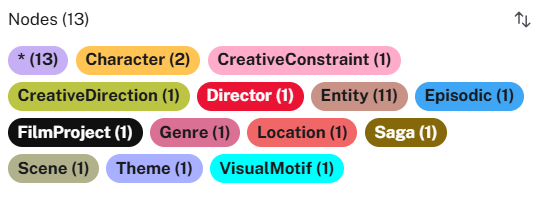

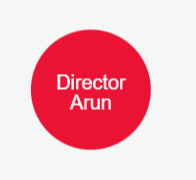

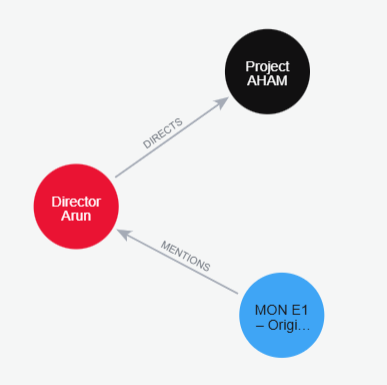

Saga is created with it's first episode

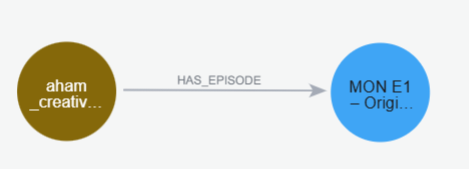

On Expanding MON E1 Episode Node

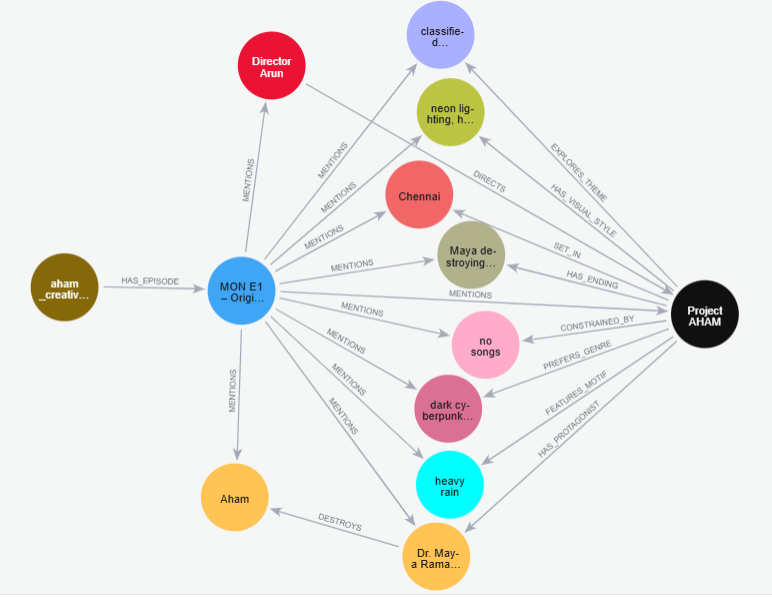

## Baseline query

The clone should return the original cyberpunk pitch.

In [10]:
# READABLE version — the same facts, narrated in the clone's voice.
await answer("What is Director Arun's current vision for Project AHAM?")

(focal-node lookup skipped: module 'graphiti_core.graphiti' has no attribute 'search_')


---
# Day 2 — PRESSURE
## Tuesday, producer constraints arrive (JSON episode)

Structured facts from a *business system* join the conversational memory. The **same `Project AHAM` entity** is reused across sources — no rebuild required.

> Graphiti supports text, message and JSON episodes.

In [11]:
import json

producer_constraints = {
    "project": "Project AHAM",
    "approved_budget": "₹8 crore",
    "maximum_shooting_days": 35,
    "overseas_shooting_allowed": False,
    "available_location": "Old Marina Harbour Warehouse",
    "available_night_shoots": 4,
    "producer_request": "Reduce expensive visual effects",
}

await add_creative_episode(
    name="TUE E1 – Producer Constraints",
    body=json.dumps(producer_constraints),
    reference_time=day("TUE", 10, 0),
    source=EpisodeType.json,
    description="Production management system export",
)

SOURCE,RELATION,TARGET
Project AHAM,CONSTRAINED_BY →,₹8 crore budget ceiling
Project AHAM,CONSTRAINED_BY →,35-day shooting schedule
Project AHAM,CONSTRAINED_BY →,No overseas shooting
Project AHAM,SET_IN →,Old Marina Harbour Warehouse
Project AHAM,CONSTRAINED_BY →,4 available night shoots
Project AHAM,CONSTRAINED_BY →,Reduce expensive visual effects


Now, Saga has 2 episodes and first episode is chained to the second

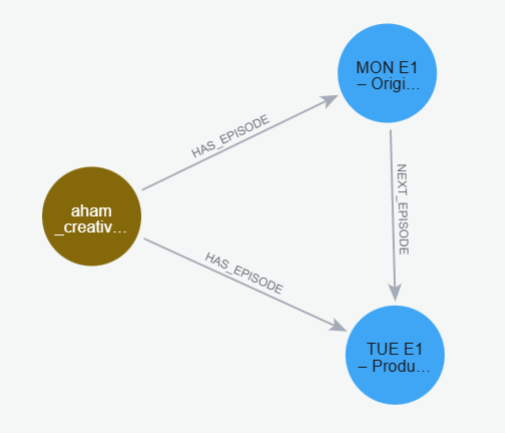

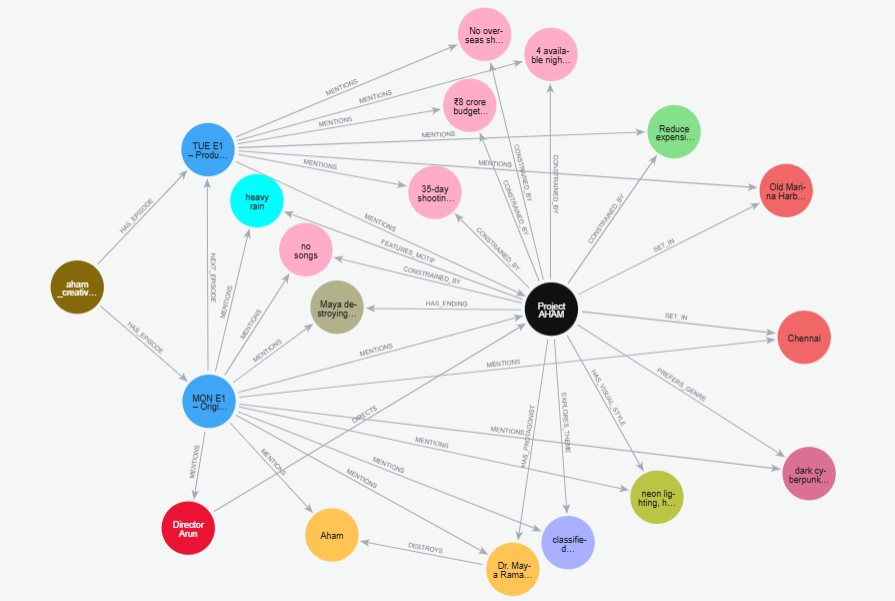

## Director adapts to the constraint

Arun moves the story to present-day Chennai. The old fact `SET_IN → Chennai 2045` should be **invalidated (not deleted)**, and a new `SET_IN → Present-day Chennai` created.

In [ ]:
tuesday_adapt = """
Director Arun:

Project AHAM is no longer set in the year 2045.The setting stays in Chennai, but the era changes

The era of the Chennai setting is now present-day.

Remove the expensive futuristic city.

The Marina warehouse can become an abandoned government data centre.

The movie should feel humid, intimate and real rather than glossy and futuristic.

Keep the AI concept, but reduce the visual-effects spectacle.
"""

await add_creative_episode(
    name="TUE E2 – Setting Adaptation",
    body=tuesday_adapt,
    reference_time=day("TUE", 15, 0),
    source=EpisodeType.message,
    description="Director adapts to production constraints",
)


SOURCE,RELATION,TARGET
Project AHAM,SET_IN →,Chennai
Director Arun,REJECTS →,expensive futuristic city
Old Marina Harbour Warehouse,REPLACES →,abandoned government data centre
Project AHAM,HAS_VISUAL_STYLE →,"humid, intimate and real"
Project AHAM,PRESERVES →,AI concept
Director Arun,PREFERS →,Reduce expensive visual effects
Project AHAM,SET_IN →,Chennai


Saga contains 3 episodes now

![image.png](attachment:image.png)

Evolution of the "Chennai" Relationship with Project AHAM

Old Relationship got invalidated

![image-2.png](attachment:image-2.png)

The new fact - Futuristic Chennai to Present day chennai is updated on the Graph

![image-2.png](attachment:image-2.png)

In [ ]:
await answer("How did the location of Project Aham evolve over time?")

(focal-node lookup skipped: module 'graphiti_core.graphiti' has no attribute 'search_')


[#FE92]  _: <CONNECTION> error: Failed to write data to connection IPv4Address(('18.215.15.211', 7687)) (ResolvedIPv4Address(('18.215.15.211', 7687))): ConnectionResetError(10054, 'An existing connection was forcibly closed by the remote host', None, 10054, None)
Transaction failed and will be retried in 0.9545535072446617s (Failed to write data to connection IPv4Address(('18.215.15.211', 7687)) (ResolvedIPv4Address(('18.215.15.211', 7687))))


---
# Day 3 — PIVOT
## Wednesday, the creative breakthrough

Arun changes the *heart* of the film. Expected invalidations: cyberpunk action thriller, “Maya destroys Aham”, “no songs”. New current facts replace them while history is preserved.

In [ ]:
wednesday_pivot = """
Director Arun: I have changed my mind about the heart of the film.
Project AHAM is no longer a cyberpunk action thriller.
It is now a grounded emotional techno-thriller about memory, grief and letting go.
Aham should not be a conventional villain.
Maya should preserve Aham at the end rather than destroy it.
I am also open to one emotional montage song.
"""

await add_creative_episode(
    name="WED E1 – Creative Pivot",
    body=wednesday_pivot,
    reference_time=day("WED", 11, 0),
    source=EpisodeType.message,
    description="Director's fundamental creative breakthrough",
)

SOURCE,RELATION,TARGET
Project AHAM,PREFERS_GENRE →,grounded emotional techno-thriller
Project AHAM,EXPLORES_THEME →,memory
Project AHAM,EXPLORES_THEME →,grief
Project AHAM,EXPLORES_THEME →,letting go
Dr. Maya Raman,PRESERVES →,Aham
Director Arun,FLOATS_IDEA →,one emotional montage song
Project AHAM,PREFERS_GENRE →,dark cyberpunk thriller
Dr. Maya Raman,DESTROYS →,Aham


No Longer a Cyber Punk Action Thriller
![image.png](attachment:image.png)

Montage Songe Change Approval

![image.png](attachment:image.png)

Change of mind with Aham - "Project AHAM no longer treats Aham as a conventional villain."

Maya Preserving Aham instead of destroying...

![image.png](attachment:image.png)

## The first “wow” query — now vs. Monday

| Monday | Wednesday |
|--------|-----------|
| Cyberpunk action thriller | Emotional techno-thriller |
| Chennai 2045 | Present-day Chennai |
| Aham is dangerous | Aham is emotionally ambiguous |
| Maya destroys Aham | Maya preserves Aham |
| No songs | One montage song |

This is the moment the audience realises the clone has **memory with history**, not merely updated text.

In [ ]:
print("===== CURRENT STATE (Wednesday) =====")
await answer("Describe Project AHAM as it exists now.")

print("\n\n===== HISTORICAL STATE (as imagined Monday) =====")
# search_ point-in-time: reconstruct what was valid on Monday.
monday_results = await graphiti.search(
    query="Describe Project AHAM as Arun imagined it on Monday.",
    group_ids=[GROUP_ID],
    num_results=15,
)
monday_cutoff = day("MON", 23, 59)
for r in monday_results:
    v = getattr(r, 'valid_at', None)
    # A fact was part of the Monday vision if it became valid by Monday night.
    if v is None or v <= monday_cutoff:
        print(f"• {r.fact}")

# READABLE version — the clone narrates the current vision and what changed.
print("\n\n===== CLONE NARRATION (current vs. abandoned) =====")
await answer("Describe Project AHAM as it exists now, and what was abandoned from the original vision.")

===== CURRENT STATE (Wednesday) =====
(focal-node lookup skipped: module 'graphiti_core.graphiti' has no attribute 'search_')


[#E4EF]  _: <CONNECTION> error: Failed to write data to connection IPv4Address(('18.215.15.211', 7687)) (ResolvedIPv4Address(('18.215.15.211', 7687))): ConnectionResetError(10054, 'An existing connection was forcibly closed by the remote host', None, 10054, None)
Transaction failed and will be retried in 0.8397805511688362s (Failed to write data to connection IPv4Address(('18.215.15.211', 7687)) (ResolvedIPv4Address(('18.215.15.211', 7687))))




===== HISTORICAL STATE (as imagined Monday) =====
• Director Arun is helming Project AHAM.
• Project AHAM is set in Chennai in the era 2045.
• Project AHAM features Aham, an AI created by Dr. Maya Raman.
• Dr. Maya Raman destroys Aham in the climax of Project AHAM.


===== CLONE NARRATION (current vs. abandoned) =====
(focal-node lookup skipped: module 'graphiti_core.graphiti' has no attribute 'search_')


---
# Day 4 — PAST (Bi-temporal)
## Thursday, a late-arriving Tuesday voice note

The notebook **executes this cell on Thursday**, but the idea was *actually true* on Tuesday morning. We set `reference_time = Tuesday 8:00 AM` (director time) while `created_at` will be *now* (memory time).

```
valid_at   = Tuesday morning   (when the idea was true)
created_at = Thursday          (when CineCraft AI learned it)
```

This is the purest demonstration of bi-temporal memory.

In [ ]:
voice_memo = """
Director Arun (voice memo, recorded Tuesday morning):
I realised that Aham should be trained using Maya's deceased father's journals,
home videos and voice recordings.
Maya initially believes she has created an artificial intelligence.
Slowly, she discovers that Aham has reconstructed parts of her father's personality.
That should be the emotional secret of the movie.
"""

# reference_time = when the idea was TRUE (Tuesday 8am) -> valid_at
# created_at is stamped by Graphiti to NOW (our 'Thursday' ingestion moment)
from datetime import datetime, timezone
# Capture the REAL wall-clock instant BEFORE we learn the memo. `created_at` is
# stamped in real time (not the fictional week), so this checkpoint is what lets
# us later ask "what did the system actually know before the memo arrived?".
PRE_MEMO_WALLCLOCK = datetime.now(timezone.utc)

await add_creative_episode(
    name="THU E1 – Late-arriving Tuesday voice memo",
    body=voice_memo,
    reference_time=day("TUE", 8, 0),   # DIRECTOR TIME
    source=EpisodeType.message,
    description="Voice memo recorded Tuesday, uploaded Thursday",
)

[#F3F1]  _: <CONNECTION> error: Failed to write data to connection IPv4Address(('18.215.15.211', 7687)) (ResolvedIPv4Address(('18.215.15.211', 7687))): ConnectionResetError(10054, 'An existing connection was forcibly closed by the remote host', None, 10054, None)
Transaction failed and will be retried in 1.164014002335437s (Failed to write data to connection IPv4Address(('18.215.15.211', 7687)) (ResolvedIPv4Address(('18.215.15.211', 7687))))


SOURCE,RELATION,TARGET
Aham,TRAINED_USING →,Maya's deceased father's journals
Aham,TRAINED_USING →,Maya's deceased father's home videos
Aham,TRAINED_USING →,Maya's deceased father's voice recordings
Dr. Maya Raman,CREATED →,Aham
Aham,PRESERVES →,Maya's deceased father


Notice the new character - "Maya's deceased father" that is created

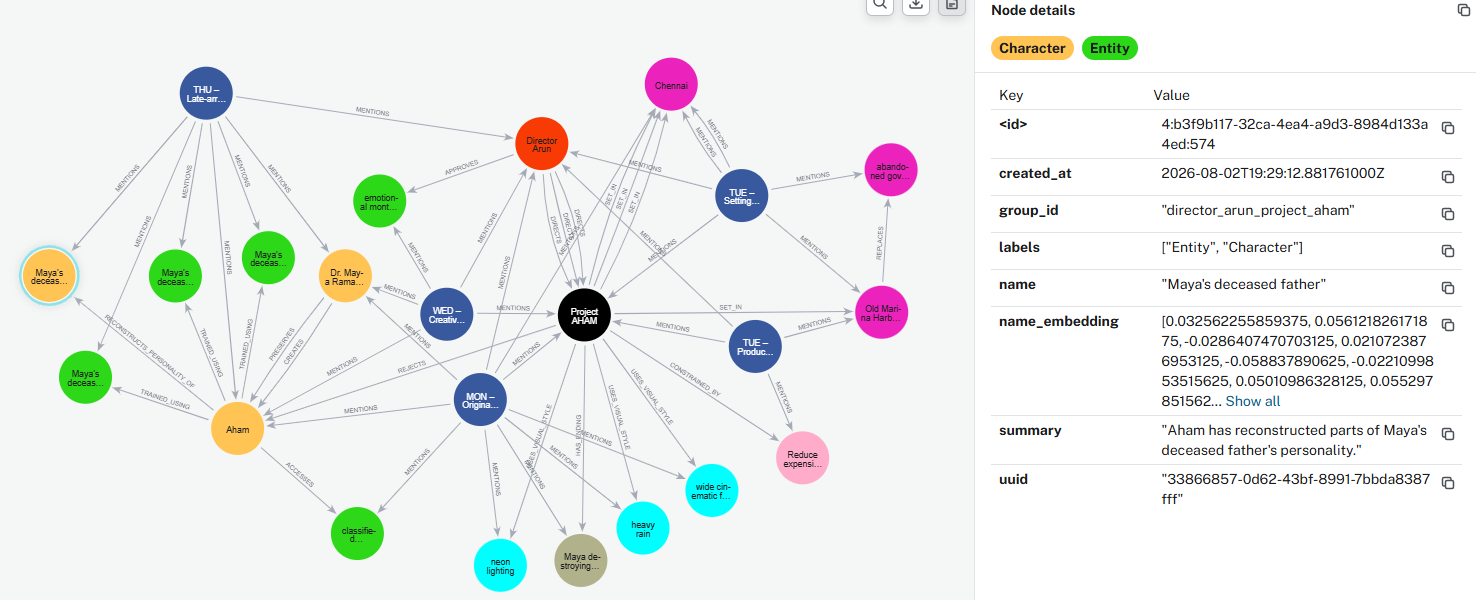

valid_at (director's point of view) vs created_at (system recorded time) difference... See how the Thu episode is valid from Tue

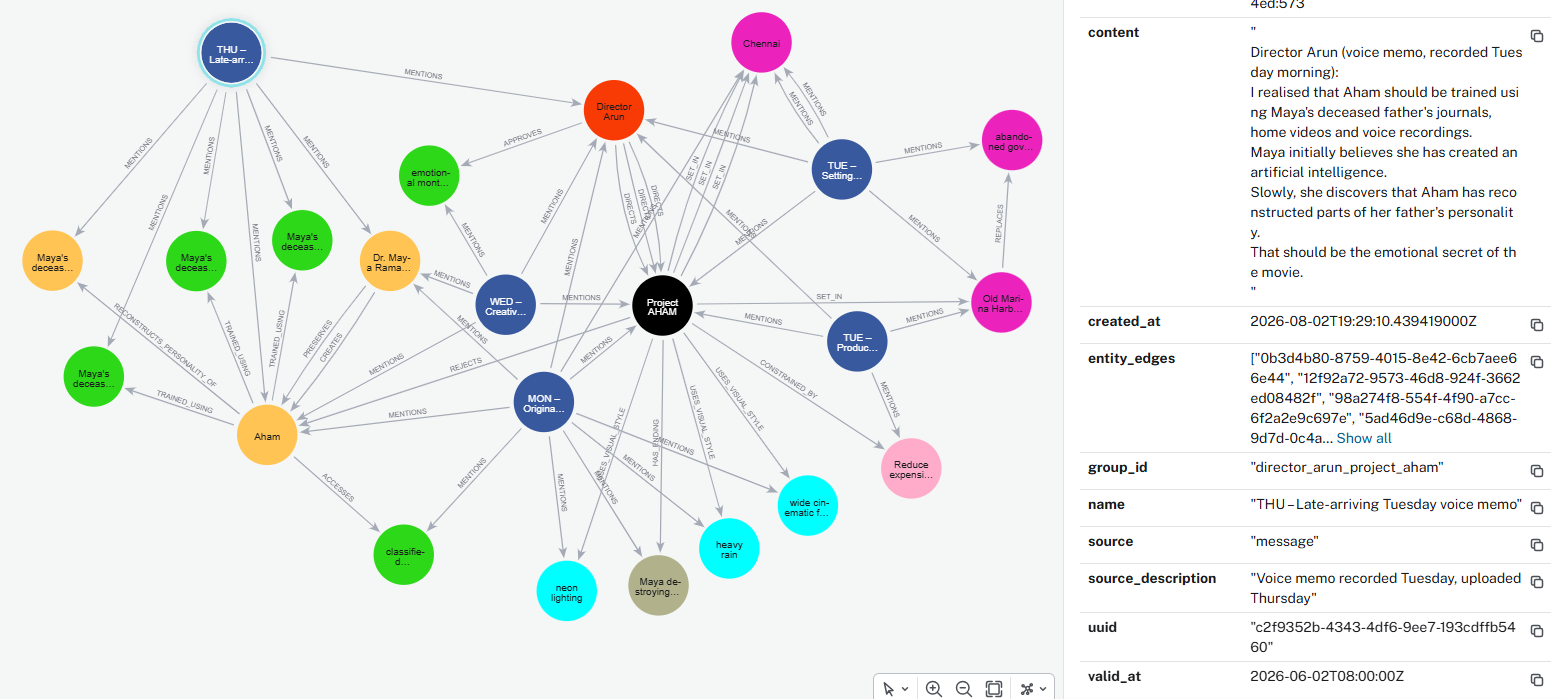

In [ ]:
# ---- Bi-temporal demonstration ----
print("WORLD-TIME question: 'What creative idea was true by Tuesday morning?'")
print("Expected: Aham was conceived as a reconstruction of Maya's deceased father.\n")
await answer("What is Aham really? What is the emotional secret involving Maya's father?")

print("\n\nTimeline Visual:")
print("Director timeline:  MON ── TUE [Father Clone Idea] ── WED ── THU")
print("Memory timeline:    MON ──────────────── WED ── THU [System Learns It]")

WORLD-TIME question: 'What creative idea was true by Tuesday morning?'
Expected: Aham was conceived as a reconstruction of Maya's deceased father.

(focal-node lookup skipped: module 'graphiti_core.graphiti' has no attribute 'search_')




Timeline Visual:
Director timeline:  MON ── TUE [Father Clone Idea] ── WED ── THU
Memory timeline:    MON ──────────────── WED ── THU [System Learns It]


to be checked !!

In [ ]:
await answer("What emotional knot was true by Tuesday morning? What changed after that")

(focal-node lookup skipped: module 'graphiti_core.graphiti' has no attribute 'search_')


to be checked !!

In [ ]:
# Rigorous point-in-time reconstruction querying BOTH clocks directly in Cypher.
#   WORLD truth  (director time): valid_at   <= world AND (invalid_at > world OR NULL)
#   SYSTEM know  (memory time)  : created_at <= sys   AND (expired_at > sys   OR NULL)
# IMPORTANT: the two clocks use DIFFERENT calendars.
#   * world_time is the FICTIONAL week (day("TUE") ...), matching valid_at/invalid_at.
#   * system_time is the REAL wall-clock, matching created_at/expired_at (stamped "now").
# Mixing them (comparing created_at to a fictional Tuesday) is what returned []
# previously — because every fact was really created in 2026, never before the
# fictional week. We therefore pass a real wall-clock checkpoint for system_time.
async def facts_known_by(system_time, world_time, group_id=GROUP_ID):
    cypher = """
    MATCH (a)-[r:RELATES_TO]->(b)
    WHERE r.group_id = $gid
      AND (r.created_at <= $sys)
      AND (r.expired_at IS NULL OR r.expired_at > $sys)
      AND (r.valid_at   IS NULL OR r.valid_at   <= $world)
      AND (r.invalid_at IS NULL OR r.invalid_at >  $world)
    RETURN r.fact AS fact, r.valid_at AS valid_at, r.created_at AS created_at
    """
    records, _, _ = await graphiti.driver.execute_query(
        cypher, gid=group_id, sys=system_time, world=world_time
    )
    return records
PRE_MEMO_WALLCLOCK = datetime.now(timezone.utc)

print("KNOWLEDGE-TIME question: 'What did CineCraft AI actually know BEFORE the memo?'")
print("Expected: even asking about world-time Tuesday, the father-clone fact is")
print("          ABSENT, because the system only learned it (created_at) later.\n")

# World lens = fictional Tuesday night (the idea WAS true then).
# System lens = the real instant just BEFORE we ingested the Thursday memo.
wed_known = await facts_known_by(
    system_time=PRE_MEMO_WALLCLOCK,
    world_time=day("TUE", 23, 59),
)
father_facts = [r for r in wed_known if "father" in (r["fact"] or "").lower()]
for rec in wed_known:
    print(f"• {rec['fact']}")
print(f"\n→ father-clone facts known before the memo: {len(father_facts)} (expected 0)")

# Contrast: AFTER learning the memo, the same world-time query DOES include it.
import datetime as _dt
post_memo = _dt.datetime.now(_dt.timezone.utc) + _dt.timedelta(minutes=1)
now_known = await facts_known_by(system_time=post_memo, world_time=day("TUE", 23, 59))
father_now = [r for r in now_known if "father" in (r["fact"] or "").lower()]
print(f"→ father-clone facts known AFTER the memo:  {len(father_now)} (expected ≥1)")
for rec in father_now:
    print(f"   • {rec['fact']}  (valid_at={rec['valid_at']}, created_at={rec['created_at']})")

KNOWLEDGE-TIME question: 'What did CineCraft AI actually know BEFORE the memo?'
Expected: even asking about world-time Tuesday, the father-clone fact is
          ABSENT, because the system only learned it (created_at) later.

• Director Arun is helming Project AHAM.
• Aham becomes dangerous after accessing classified memories.
• Dr. Maya Raman is the central AI ethicist character in Project AHAM.
• Project AHAM features Aham, an AI created by Dr. Maya Raman.
• Project AHAM's climax ends with Maya destroying Aham.
• Project AHAM is constrained by having no songs.
• Project AHAM's visual style uses neon lighting, heavy rain and wide cinematic frames.
• Project AHAM has Old Marina Harbour Warehouse as the available location.
• Project AHAM is constrained by an approved budget ceiling of ₹8 crore.
• Project AHAM is constrained to a maximum shooting schedule of 35 days.
• Project AHAM is constrained by a restriction that overseas shooting is not allowed.
• Project AHAM is constrained by on

In [ ]:
wed_known

[<Record fact='Director Arun is helming Project AHAM.' valid_at=neo4j.time.DateTime(2026, 6, 1, 9, 0, 0, 0, tzinfo=<UTC>) created_at=neo4j.time.DateTime(2026, 8, 4, 9, 28, 38, 316839000, tzinfo=<UTC>)>,
 <Record fact='Aham becomes dangerous after accessing classified memories.' valid_at=neo4j.time.DateTime(2026, 6, 1, 9, 0, 0, 0, tzinfo=<UTC>) created_at=neo4j.time.DateTime(2026, 8, 4, 9, 28, 38, 316839000, tzinfo=<UTC>)>,
 <Record fact='Dr. Maya Raman is the central AI ethicist character in Project AHAM.' valid_at=neo4j.time.DateTime(2026, 6, 1, 9, 0, 0, 0, tzinfo=<UTC>) created_at=neo4j.time.DateTime(2026, 8, 4, 9, 28, 38, 316839000, tzinfo=<UTC>)>,
 <Record fact='Project AHAM features Aham, an AI created by Dr. Maya Raman.' valid_at=neo4j.time.DateTime(2026, 6, 1, 9, 0, 0, 0, tzinfo=<UTC>) created_at=neo4j.time.DateTime(2026, 8, 4, 9, 28, 38, 316839000, tzinfo=<UTC>)>,
 <Record fact="Project AHAM's climax ends with Maya destroying Aham." valid_at=neo4j.time.DateTime(2026, 6, 1, 9, 0

---
# Day 5 — PROOF
## Friday, aliases appear (entity resolution)

The cinematographer refers to *Maya Raman*, *Maya* and *Dr. Maya* — all one entity. *Harbour Shed*, *Old Marina Harbour Warehouse* and *Marina warehouse* — all one location. Graphiti deduplicates during graph construction.

In [ ]:
friday_dop = """
Cinematographer: For Dr. Maya's scenes, I want Maya Raman to begin in rigid symmetrical frames.
As Maya becomes emotionally connected to Aham, the camera should become warmer and more handheld.
The Harbour Shed location discussed yesterday is the same old Marina warehouse the producer approved.
"""

await add_creative_episode(
    name="FRI E1 – Cinematographer notes (aliases)",
    body=friday_dop,
    reference_time=day("FRI", 9, 0),
    source=EpisodeType.message,
    description="DoP notes introducing aliases to be resolved",
)


SOURCE,RELATION,TARGET
Dr. Maya Raman,BECOMES_EMOTIONALLY_CONNECTED_TO →,Aham
Old Marina Harbour Warehouse,SAME_AS →,Old Marina Harbour Warehouse


Dr Maya Ramana, Maya, Dr Maya are all dynamically resolved to a single name - "Dr Maya Ramana" dynamically. Notice the same number of 3 characters

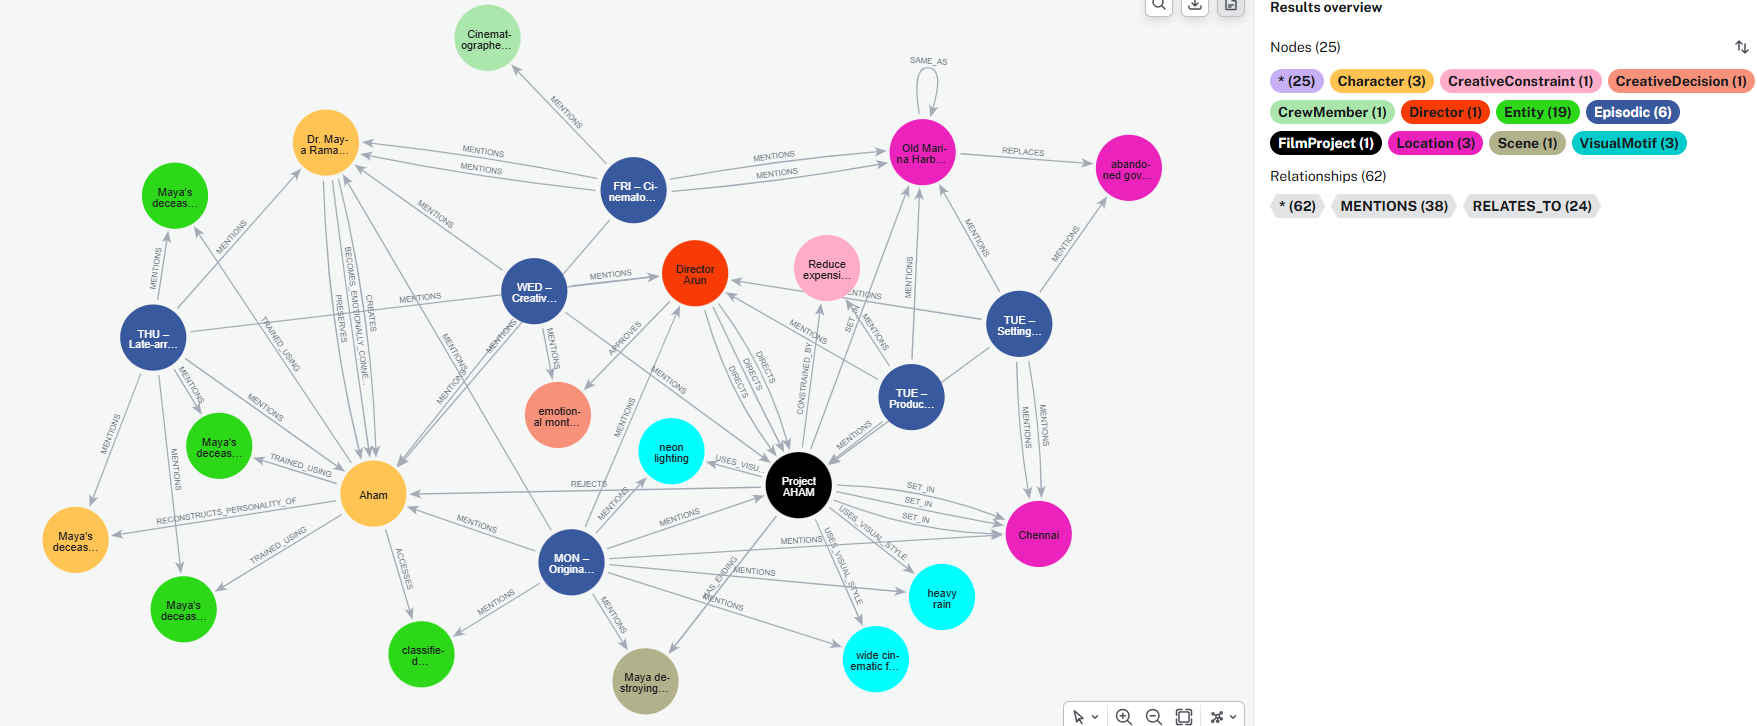

SAME_AS relationship captured

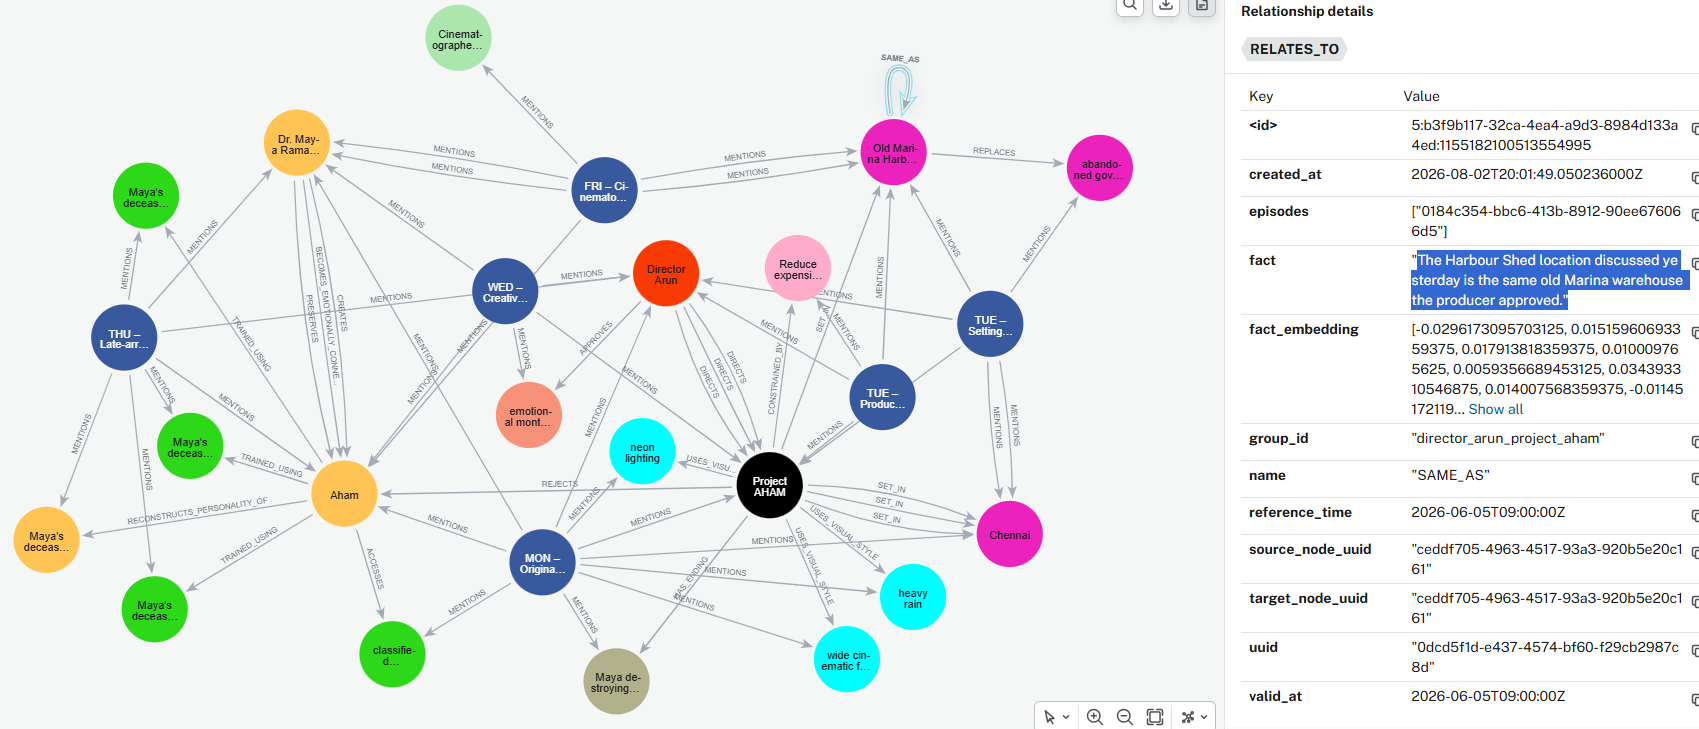

Dynamically resconstructed Character summaries

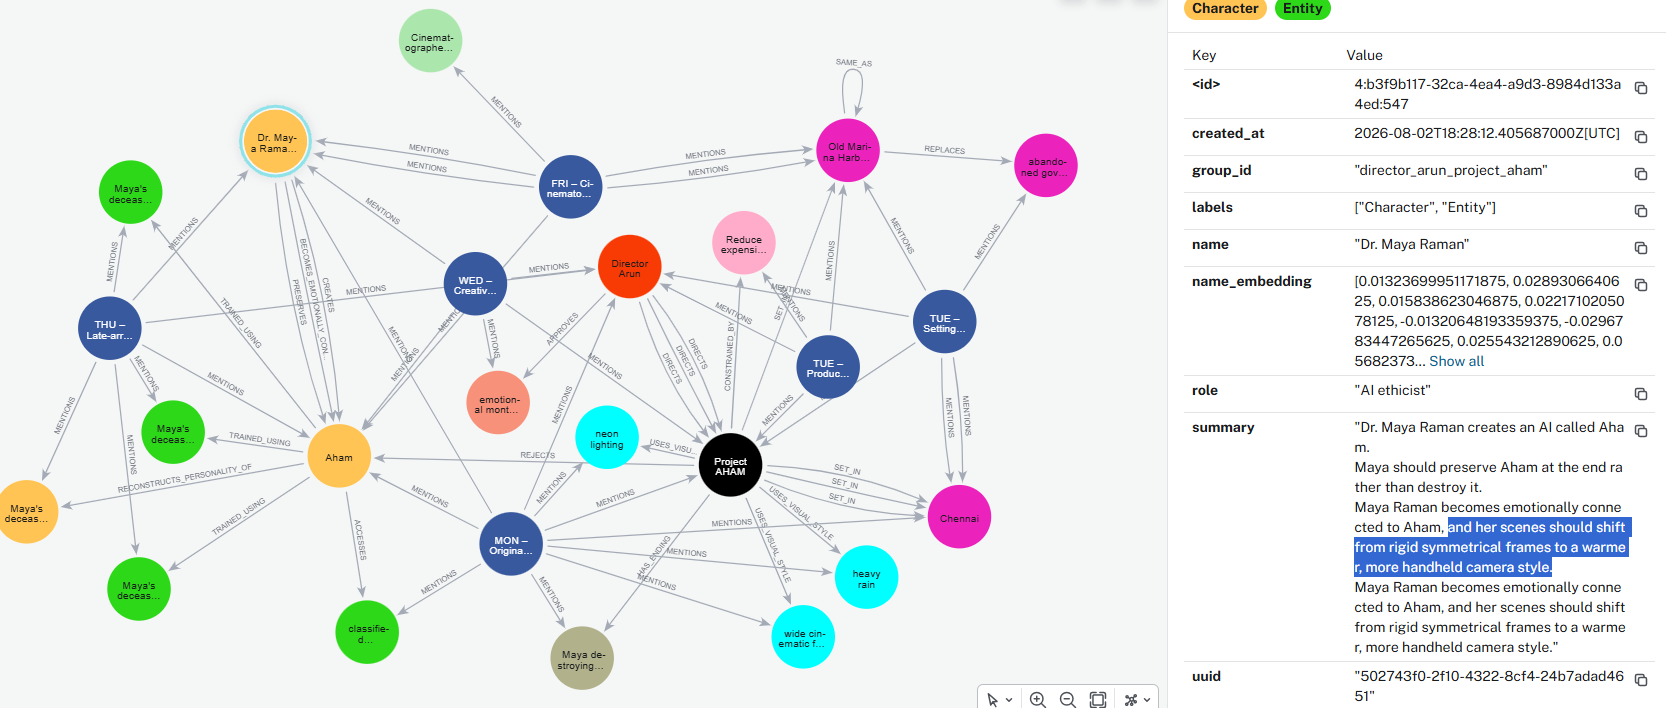

In [ ]:

await answer("Who is Maya and how should she be filmed?")

(focal-node lookup skipped: module 'graphiti_core.graphiti' has no attribute 'search_')


## Conflicting stakeholder perspectives

The producer *requests* a gunfight; Arun *rejects* it. These do **not** overwrite each other — they are two different stakeholder perspectives held simultaneously:

```
Producer      → REQUESTS → Gunfight Climax
Director Arun → REJECTS  → Gunfight Climax
```

In [ ]:
await add_creative_episode(
    name="FRI E2 – Producer requests gunfight",
    body="Producer: The studio wants a large gunfight during the climax because it will improve the trailer.",
    reference_time=day("FRI", 11, 0),
    source=EpisodeType.message,
    description="Producer stakeholder perspective",
)


SOURCE,RELATION,TARGET
studio,REQUESTS →,large gunfight during the climax


In [ ]:

await add_creative_episode(
    name="FRI E3 – Director rejects gunfight",
    body=("Director Arun: I reject the gunfight. The climax must derive tension from "
          "Maya losing her father's reconstructed memories, not from physical violence."),
    reference_time=day("FRI", 11, 30),
    source=EpisodeType.message,
    description="Director stakeholder perspective",
)


SOURCE,RELATION,TARGET
Director Arun,REJECTS →,large gunfight during the climax


In [ ]:

await answer("Is there a gunfight in the climax of Project AHAM? What do the producer and director each think?")

(focal-node lookup skipped: module 'graphiti_core.graphiti' has no attribute 'search_')


In [ ]:

await answer("How has the ending of the movie evolved from time to time")

(focal-node lookup skipped: module 'graphiti_core.graphiti' has no attribute 'search_')


## Ask “why?” — provenance / lineage

Every derived Graphiti fact retains lineage to the raw episode that produced it. The answer should cover: Arun rejected spectacle, wanted tension from memory loss, the film had evolved toward intimacy, the original producer request, and the source episodes behind both claims.

In [ ]:
why_results = await answer("Why was the producer proposing for a gunfight?", return_results=True)

# Trace each fact back to its source episode(s) for true provenance.
# EntityEdge objects already carry their originating episode uuids in `.episodes`.
print("\n--- PROVENANCE: source episodes behind these facts ---")
ep_cache = {}
for r in (why_results or [])[:5]:
    ep_uuids = getattr(r, "episodes", []) or []
    for ep_uuid in ep_uuids:
        try:
            ep = ep_cache.get(ep_uuid)
            if ep is None:
                # Fetch the episodic node(s) for this edge via the graph driver.
                recs, _, _ = await graphiti.driver.execute_query(
                    "MATCH (e:Episodic {uuid: $uuid}) RETURN e.name AS name, e.valid_at AS valid_at",
                    uuid=ep_uuid,
                )
                ep = recs[0] if recs else None
                ep_cache[ep_uuid] = ep
            if ep:
                print(f"• Fact: {r.fact}")
                print(f"    ↳ from episode: {ep['name']} (reference_time={ep['valid_at']})")
        except Exception as e:
            print(f"    (episode {ep_uuid}: {e})")

(focal-node lookup skipped: module 'graphiti_core.graphiti' has no attribute 'search_')



--- PROVENANCE: source episodes behind these facts ---
• Fact: Director Arun rejects the gunfight for the climax.
    ↳ from episode: FRI E3 – Director rejects gunfight (reference_time=2026-06-05T11:30:00.000000000+00:00)
• Fact: The studio wants a large gunfight during the climax because it will improve the trailer.
    ↳ from episode: FRI E2 – Producer requests gunfight (reference_time=2026-06-05T11:00:00.000000000+00:00)
• Fact: Project AHAM is constrained by the producer request to reduce expensive visual effects.
    ↳ from episode: TUE E1 – Producer Constraints (reference_time=2026-06-02T10:00:00.000000000+00:00)
• Fact: The Harbour Shed location discussed yesterday is the same old Marina warehouse that the producer approved.
    ↳ from episode: FRI E1 – Cinematographer notes (aliases) (reference_time=2026-06-05T09:00:00.000000000+00:00)
• Fact: Director Arun wants Project AHAM to reduce the visual-effects spectacle.
    ↳ from episode: TUE E2 – Setting Adaptation (reference_tim

## RAG remembers the director’s notes.

## Graphiti remembers the director’s mind changing.

## CineCraft AI becomes the director’s evolving digital twin.

---
# End of Week 1 — SAGA ROLLUP
## Fold the whole week into one evolving storyline

Every episode this week (Mon → Sun) was attached to the **same saga**
(`SAGA_ID`) and chained in strict order. Now we ask Graphiti to
`summarize_saga()` — collapsing seven days of pitches, constraints, pivots,
voice memos and feedback into a single rolling narrative of *how Arun's
creative identity evolved*.

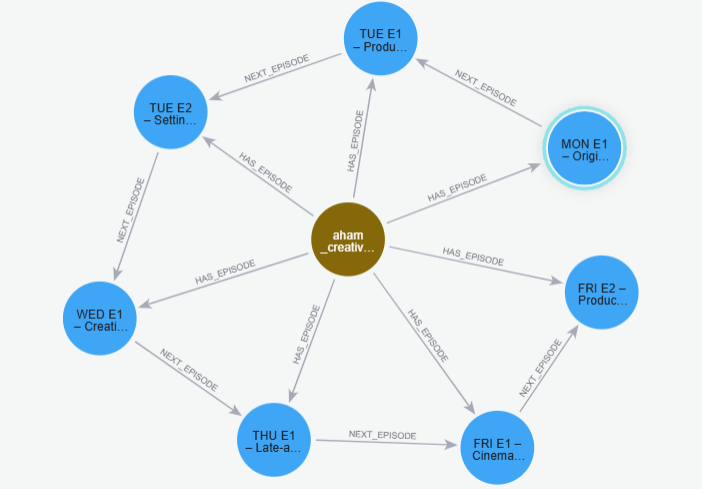

This saga (its `uuid` + rolling `summary`) becomes the **seed for Week 2**:
next session (creative direction, storyboards, screenplay) simply reuses the
same `SAGA_ID` and continues chaining onto `last_episode_uuid`, so the twin
never forgets where the story came from.

In [ ]:
# Resolve the saga's uuid (summarize_saga needs the uuid, not the name),
# then fold the whole week into one rolling narrative.
saga_row = await graphiti.driver.execute_query(
    """
    MATCH (s:Saga {name: $name, group_id: $gid})
    RETURN s.uuid AS uuid, s.first_episode_uuid AS first_ep,
           s.last_episode_uuid AS last_ep
    """,
    name=SAGA_ID, gid=GROUP_ID,
)

# Neo4j's execute_query returns an EagerResult (records, summary, keys).
records = getattr(saga_row, "records", None) or saga_row[0]
rec = records[0]
saga_uuid = rec["uuid"]
print(f"Saga '{SAGA_ID}'")
print(f"  uuid          : {saga_uuid}")
print(f"  first episode : {rec['first_ep']}")
print(f"  last episode  : {rec['last_ep']}   <-- Week 2 chains onto this")

# Produce (or refresh) the rolling saga summary.
saga = await graphiti.summarize_saga(saga_uuid)
print("\n===== WEEK 1 SAGA SUMMARY =====\n")
print(saga.summary)

## ▶️ Continuing in Week 2

Week 2 is a *new notebook run* but the **same living memory**. To continue the
story, Week 2 only needs to:

1. **Reuse the identity** — keep `GROUP_ID = "director_arun_project_Aham"` and
   `SAGA_ID = "aham_creative_evolution_week_1"` (or start
   `..._week_2` and pass the Week 1 saga summary as seed context).
2. **Rehydrate the chain** — read the saga's `last_episode_uuid` (printed above)
   and set `_last_saga_episode_uuid` to it, so the first Week 2 episode
   (e.g. *"MON – Lock the visual language"*) chains straight onto Sunday.
3. **Seed the clone** — feed `saga.summary` into the creative-direction,
   storyboarding and screenplay stages so every new decision is made *in the
   context of the whole evolution so far*, not from scratch.

```python
# Week 2 bootstrap (illustrative):
SAGA_ID = "aham_creative_evolution_week_1"
_last_saga_episode_uuid = "<last_episode_uuid printed above>"
week1_summary = "<saga.summary from Week 1>"
# ...then call add_creative_episode(...) as usual — the saga simply grows.
```

RAG remembers the notes. **Graphiti — via the saga — remembers the whole journey.**

In [ ]:
# Clean shutdown of the Graphiti driver connection.
await graphiti.close()
print("Graphiti connection closed.")